In [1]:
pip install mlxtend

INFO: pip is looking at multiple versions of mlxtend to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 23.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
# =====================================
# STEP 1 — IMPORT LIBRARIES
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [3]:
# =====================================
# STEP 2 — LOAD DATA
# =====================================

df = pd.read_csv("Global_Pollution_Analysis.csv")

print(df.shape)
df.head()

(200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [4]:
# =====================================
# STEP 3 — HANDLE MISSING VALUES
# =====================================

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [5]:
# =====================================
# STEP 4 — SCALE POLLUTION FEATURES
# =====================================

pollution_cols = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index"
]

scaler = StandardScaler()

df[pollution_cols] = scaler.fit_transform(df[pollution_cols])

In [6]:
# =====================================
# STEP 5 — LABEL ENCODING
# =====================================

encoder = LabelEncoder()

df["Country"] = encoder.fit_transform(df["Country"])
df["Year"] = encoder.fit_transform(df["Year"])

In [7]:
# =====================================
# STEP 6A — NEW FEATURE
# =====================================

df["Energy_per_Capita"] = (
    df["Energy_Consumption_Per_Capita (in MWh)"]
    / df["Population (in millions)"]
)

In [8]:
# =====================================
# STEP 6B — POLLUTION SEVERITY
# =====================================

def categorize(x):
    if x < -0.5:
        return "Low"
    elif x < 0.5:
        return "Medium"
    else:
        return "High"

df["Air_Level"] = df["Air_Pollution_Index"].apply(categorize)
df["Water_Level"] = df["Water_Pollution_Index"].apply(categorize)
df["Soil_Level"] = df["Soil_Pollution_Index"].apply(categorize)

In [15]:
# =====================================
# STEP 7 — PREPARE DATA FOR APRIORI
# =====================================

apriori_df = df[[
    "Air_Level",
    "Water_Level",
    "Soil_Level",
    "Renewable_Energy (%)"
]].copy()

In [16]:
# =====================================
# STEP 7B — RENEWABLE CATEGORY
# =====================================

def energy_cat(x):
    if x < 30:
        return "Low_Renewable"
    elif x < 60:
        return "Medium_Renewable"
    else:
        return "High_Renewable"

apriori_df["Renewable_Level"] = apriori_df["Renewable_Energy (%)"].apply(energy_cat)

In [17]:
apriori_df = apriori_df.drop(columns=["Renewable_Energy (%)"])

In [18]:
# =====================================
# STEP 8 — ONE HOT ENCODING
# =====================================

basket = pd.get_dummies(apriori_df)

basket.head()

,Air_Level_High,Air_Level_Low,Air_Level_Medium,Water_Level_High,Water_Level_Low,Water_Level_Medium,Soil_Level_High,Soil_Level_Low,Soil_Level_Medium,Renewable_Level_Low_Renewable,Renewable_Level_Medium_Renewable
0,True,False,False,False,False,True,False,True,False,False,True
1,False,True,False,False,True,False,True,False,False,False,True
2,False,True,False,False,True,False,True,False,False,True,False
3,True,False,False,False,True,False,False,False,True,True,False
4,False,False,True,False,False,True,True,False,False,False,True


In [19]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(basket, min_support=0.1, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

rules.sort_values("lift", ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Soil_Level_Medium),(Renewable_Level_Low_Renewable),0.28,0.51,0.18,0.642857,1.260504,1.0,0.0372,1.372,0.287037,0.295082,0.271137,0.497899


In [20]:
print(apriori_df.columns)

Index(['Air_Level', 'Water_Level', 'Soil_Level', 'Renewable_Level'], dtype='object')


In [21]:
# =====================================
# STEP 8 — ONE HOT ENCODING
# =====================================

basket = pd.get_dummies(apriori_df)

print(basket.head())

   Air_Level_High  Air_Level_Low  Air_Level_Medium  Water_Level_High  \
0            True          False             False             False   
1           False           True             False             False   
2           False           True             False             False   
3            True          False             False             False   
4           False          False              True             False   

   Water_Level_Low  Water_Level_Medium  Soil_Level_High  Soil_Level_Low  \
0            False                True            False            True   
1             True               False             True           False   
2             True               False             True           False   
3             True               False            False           False   
4            False                True             True           False   

   Soil_Level_Medium  Renewable_Level_Low_Renewable  \
0              False                          False   
1     

In [22]:
# =====================================
# STEP 9 — FREQUENT ITEMSETS
# =====================================

from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.1,
    use_colnames=True
)

print(frequent_itemsets.sort_values("support", ascending=False))

    support                                           itemsets
9     0.510                    (Renewable_Level_Low_Renewable)
10    0.490                 (Renewable_Level_Medium_Renewable)
6     0.365                                  (Soil_Level_High)
2     0.355                                 (Air_Level_Medium)
4     0.355                                  (Water_Level_Low)
7     0.355                                   (Soil_Level_Low)
0     0.340                                   (Air_Level_High)
3     0.340                                 (Water_Level_High)
5     0.305                               (Water_Level_Medium)
1     0.305                                    (Air_Level_Low)
8     0.280                                (Soil_Level_Medium)
46    0.200  (Renewable_Level_Medium_Renewable, Soil_Level_...
29    0.195  (Air_Level_Medium, Renewable_Level_Medium_Rene...
44    0.190  (Renewable_Level_Medium_Renewable, Soil_Level_...
33    0.185  (Water_Level_High, Renewable_Level_Low_Ren

In [23]:
# =====================================
# STEP 10 — ASSOCIATION RULES
# =====================================

from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

rules = rules.sort_values("lift", ascending=False)

print(rules)

           antecedents                      consequents  antecedent support  \
0  (Soil_Level_Medium)  (Renewable_Level_Low_Renewable)                0.28   

   consequent support  support  confidence      lift  representativity  \
0                0.51     0.18    0.642857  1.260504               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
0    0.0372       1.372       0.287037  0.295082   0.271137    0.497899  


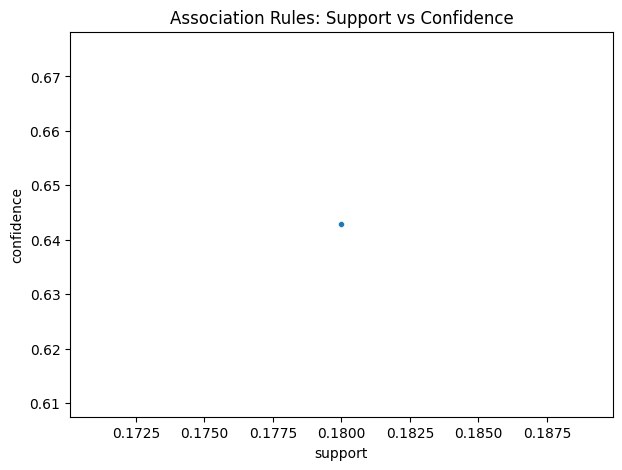

In [24]:
# =====================================
# STEP 11 — VISUALIZATION
# =====================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=rules["support"],
    y=rules["confidence"],
    size=rules["lift"],
    legend=False
)

plt.title("Association Rules: Support vs Confidence")
plt.show()

In [25]:
# =====================================
# STEP 12 — TOP ASSOCIATION RULES
# =====================================

top_rules = rules.head()

print(top_rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]])

           antecedents                      consequents  support  confidence  \
0  (Soil_Level_Medium)  (Renewable_Level_Low_Renewable)     0.18    0.642857   

       lift  
0  1.260504  


In [26]:
# =====================================
# STEP 13 — RECOMMENDATIONS
# =====================================

print("\n📌 KEY INSIGHTS")

print("""
• High pollution levels are often associated with lower renewable energy adoption.
• Medium pollution countries show potential for improvement.
• Renewable energy expansion can reduce pollution severity.
• Association rules help policymakers target high-risk regions.
""")


📌 KEY INSIGHTS

• High pollution levels are often associated with lower renewable energy adoption.
• Medium pollution countries show potential for improvement.
• Renewable energy expansion can reduce pollution severity.
• Association rules help policymakers target high-risk regions.



In [27]:
# =====================================
# STEP 14 — RULE QUALITY ANALYSIS
# =====================================

print("\n📊 Rule Quality Summary")

print("Average Support:", rules["support"].mean())
print("Average Confidence:", rules["confidence"].mean())
print("Average Lift:", rules["lift"].mean())


📊 Rule Quality Summary
Average Support: 0.18
Average Confidence: 0.6428571428571428
Average Lift: 1.2605042016806722


In [28]:
# =====================================
# STEP 15 — STRONGEST RULES
# =====================================

strong_rules = rules[rules["lift"] > 1].sort_values("lift", ascending=False)

print("\n🔥 Strongest Association Rules:")
print(strong_rules.head())


🔥 Strongest Association Rules:
           antecedents                      consequents  antecedent support  \
0  (Soil_Level_Medium)  (Renewable_Level_Low_Renewable)                0.28   

   consequent support  support  confidence      lift  representativity  \
0                0.51     0.18    0.642857  1.260504               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
0    0.0372       1.372       0.287037  0.295082   0.271137    0.497899  


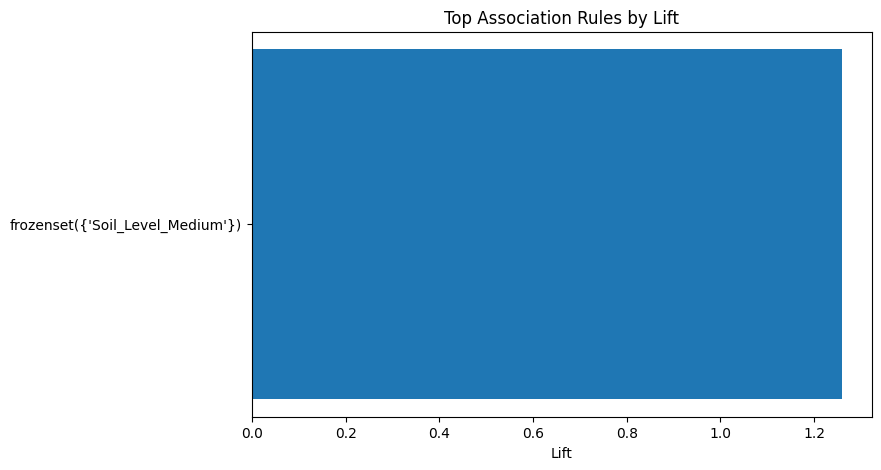

In [29]:
# =====================================
# STEP 16 — TOP RULES VISUALIZATION
# =====================================

top5 = strong_rules.head(5)

plt.figure(figsize=(8,5))

plt.barh(
    range(len(top5)),
    top5["lift"]
)

plt.yticks(range(len(top5)), top5["antecedents"].astype(str))
plt.xlabel("Lift")
plt.title("Top Association Rules by Lift")
plt.show()

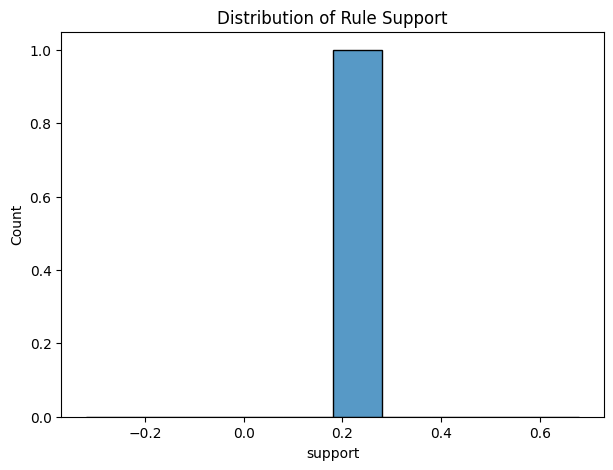

In [30]:
# =====================================
# STEP 17 — SUPPORT DISTRIBUTION
# =====================================

plt.figure(figsize=(7,5))

sns.histplot(rules["support"], bins=10)

plt.title("Distribution of Rule Support")
plt.show()

In [31]:
# =====================================
# STEP 18 — FINAL CONCLUSION
# =====================================

print("\n📌 FINAL CONCLUSION")

print("""
• Apriori algorithm successfully identified relationships between pollution levels and renewable energy usage.
• High pollution levels frequently occur with low renewable energy adoption.
• Medium pollution regions present opportunities for sustainable intervention.
• Strong association rules can guide environmental policy decisions.
• Data-driven strategies can improve pollution control and energy optimization.
""")


📌 FINAL CONCLUSION

• Apriori algorithm successfully identified relationships between pollution levels and renewable energy usage.
• High pollution levels frequently occur with low renewable energy adoption.
• Medium pollution regions present opportunities for sustainable intervention.
• Strong association rules can guide environmental policy decisions.
• Data-driven strategies can improve pollution control and energy optimization.



In [32]:
# =====================================
# STEP 19 — SAVE OUTPUT
# =====================================

rules.to_csv("association_rules_output.csv", index=False)

print("Association rules saved successfully ✅")

Association rules saved successfully ✅
